In [1]:
import os
import cv2
import torch
import numpy as np
import albumentations as A
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ==============================
# 1. CONFIGURATION
# ==============================
PROCESSED_DIR = "processed_datasettttt"
IMG_IDS = os.listdir(os.path.join(PROCESSED_DIR, "images"))

# Split data into training and validation sets
from sklearn.model_selection import train_test_split
TRAIN_IDS, VAL_IDS = train_test_split(IMG_IDS, test_size=0.2, random_state=42)

# Use CUDA if available, else fallback to CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

# ==============================
# 2. PYTORCH DATASET CLASS
# ==============================
class ForgeryDataset(Dataset):
    def __init__(self, image_ids, directory, transform=None):
        self.image_ids = image_ids
        self.directory = directory
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        # --- File Paths ---
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.directory, "images", img_name)
        mask_path = os.path.join(self.directory, "masks", img_name)
        ela_path = os.path.join(self.directory, "ela_images", img_name)
        hpf_path = os.path.join(self.directory, "hpf_images", img_name)

        # --- Load Images ---
        # Load as RGB, ELA as Grayscale, HPF as Grayscale
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        ela = cv2.imread(ela_path, cv2.IMREAD_GRAYSCALE)
        hpf = cv2.imread(hpf_path, cv2.IMREAD_GRAYSCALE)
        
        # --- Combine Inputs ---
        # Stack grayscale ELA and HPF onto the RGB image to create a 5-channel input
        # We need to add a dimension to grayscale images before stacking
        combined_image = np.dstack([image, ela, hpf])
        
        # --- Binarize Mask ---
        # Ensure mask is 0 or 1
        mask = (mask / 255.0).astype(np.float32)

        # --- Apply Augmentations ---
        if self.transform:
            augmented = self.transform(image=combined_image, mask=mask)
            combined_image = augmented['image']
            mask = augmented['mask']
        
        return combined_image, mask

# ==============================
# 3. AUGMENTATIONS & DATALOADERS
# ==============================
# Define augmentations for training and validation
# Note: Normalization for 5 channels needs a custom mean/std
# We use ImageNet stats for RGB and 0.5 for ELA/HPF
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.5, 0.5), std=(0.229, 0.224, 0.225, 0.5, 0.5)),
    A.pytorch.transforms.ToTensorV2(),
])

# Create Dataset objects
train_dataset = ForgeryDataset(TRAIN_IDS, PROCESSED_DIR, transform=transform)
val_dataset = ForgeryDataset(VAL_IDS, PROCESSED_DIR, transform=transform)

# Create DataLoader objects
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Using device: cuda
Training samples: 4098, Validation samples: 1025


In [2]:
import segmentation_models_pytorch as smp

# Define the model using a compatible and powerful encoder
model = smp.Unet(
    encoder_name="tu-efficientnet_b5",  # <-- The fix is here! Using a compatible EfficientNet.
    encoder_weights="imagenet",
    in_channels=5,
    classes=1,
    activation='sigmoid'
)

model.to(DEVICE)
print("Model defined and moved to device.")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model defined and moved to device.


Using device: cuda


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



--- Epoch 1/10 ---


Validating: 100%|█████████████████████████████████████████████████| 129/129 [01:35<00:00,  1.35it/s, iou=0, loss=0.972]


Epoch 1 | Train Loss: 0.8300 | Train IoU: 0.1907 | Val Loss: 0.8382 | Val IoU: 0.2136
✅ Model saved at epoch 1 with validation IoU: 0.2136

--- Epoch 2/10 ---


...

Epoch 8 | Train Loss: 0.8136 | Train IoU: 0.3637 | Val Loss: 0.8299 | Val IoU: 0.3137

--- Epoch 9/10 ---


Validating: 100%|█████████████████████████████████████████████████| 129/129 [00:10<00:00, 12.27it/s, iou=0, loss=0.972]


Epoch 9 | Train Loss: 0.8097 | Train IoU: 0.4469 | Val Loss: 0.8279 | Val IoU: 0.3673

--- Epoch 10/10 ---


Validating: 100%|█████████████████████████████████████████████████| 129/129 [00:10<00:00, 12.13it/s, iou=0, loss=0.972]


Epoch 10 | Train Loss: 0.8105 | Train IoU: 0.4139 | Val Loss: 0.8304 | Val IoU: 0.3199

--- Training Finished ---


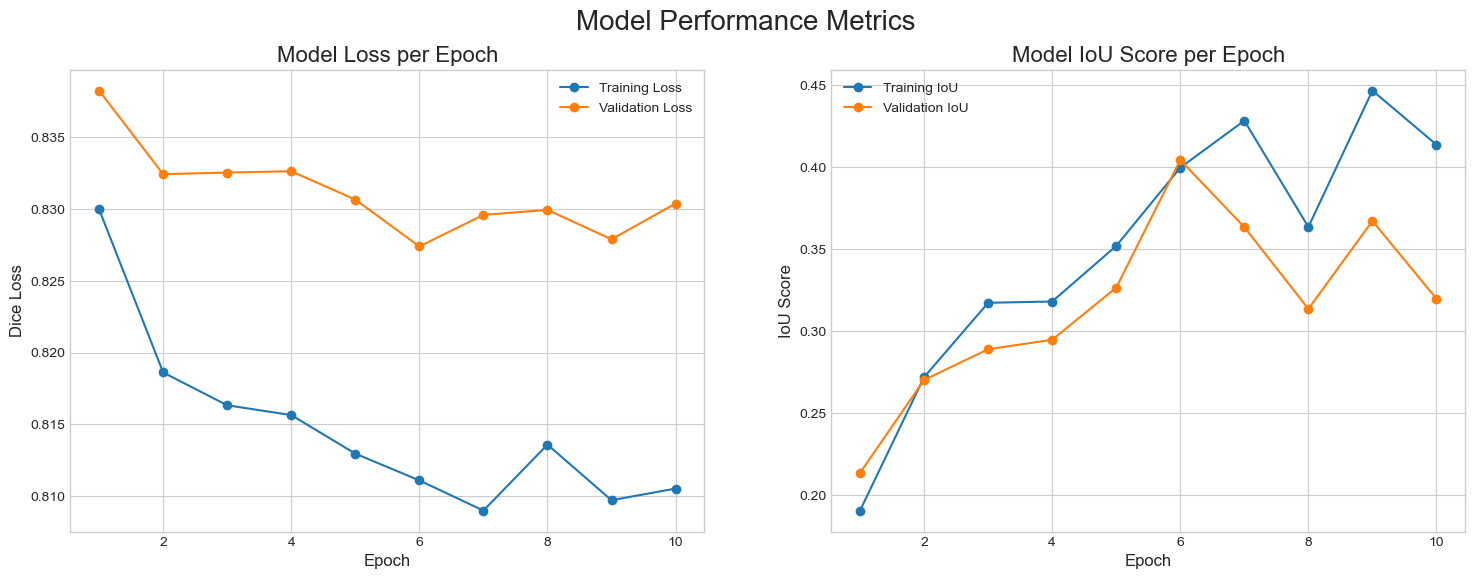

In [3]:
import os
import cv2
import torch
import numpy as np
import albumentations as A
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.metrics import iou_score, get_stats
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==============================
# 1. CONFIGURATION
# ==============================
PROCESSED_DIR = "processed_datasettttt"
IMG_IDS = os.listdir(os.path.join(PROCESSED_DIR, "images"))
TRAIN_IDS, VAL_IDS = train_test_split(IMG_IDS, test_size=0.2, random_state=42)

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

# ==============================
# 2. PYTORCH DATASET AND DATALOADERS
# ==============================
class ForgeryDataset(Dataset):
    def __init__(self, image_ids, directory, transform=None):
        self.image_ids = image_ids
        self.directory = directory
        self.transform = transform
    def __len__(self):
        return len(self.image_ids)
    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.directory, "images", img_name)
        mask_path = os.path.join(self.directory, "masks", img_name)
        ela_path = os.path.join(self.directory, "ela_images", img_name)
        hpf_path = os.path.join(self.directory, "hpf_images", img_name)
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        ela = cv2.imread(ela_path, cv2.IMREAD_GRAYSCALE)
        hpf = cv2.imread(hpf_path, cv2.IMREAD_GRAYSCALE)
        combined_image = np.dstack([image, ela, hpf])
        mask = (mask / 255.0).astype(np.float32)
        if self.transform:
            augmented = self.transform(image=combined_image, mask=mask)
            combined_image = augmented['image']
            mask = augmented['mask']
        return combined_image, mask

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.5, 0.5), std=(0.229, 0.224, 0.225, 0.5, 0.5)),
    A.pytorch.transforms.ToTensorV2(),
])

train_dataset = ForgeryDataset(TRAIN_IDS, PROCESSED_DIR, transform=transform)
val_dataset = ForgeryDataset(VAL_IDS, PROCESSED_DIR, transform=transform)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# 3. DEFINE MODEL, LOSS, AND OPTIMIZER
# ==============================
model = smp.Unet(
    encoder_name="tu-efficientnet_b5", encoder_weights="imagenet", in_channels=5, classes=1, activation='sigmoid'
)
model.to(DEVICE)

loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# ==============================
# 4. TRAINING & VALIDATION FUNCTIONS
# ==============================
def train_epoch(loader, model, optimizer, loss_fn, device):
    model.train()
    loop = tqdm(loader, desc="Training")
    running_loss = 0.0
    total_iou = 0.0
    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)
        if masks.ndim == 3: masks = masks.unsqueeze(1)
        
        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate IoU for the training batch
        preds = (outputs > 0.5)
        gt = (masks > 0.5)
        tp, fp, fn, tn = get_stats(preds.long(), gt.long(), mode='binary')
        iou = iou_score(tp, fp, fn, tn, reduction='micro')
        
        running_loss += loss.item()
        total_iou += iou.item()
        loop.set_postfix(loss=loss.item(), iou=iou.item())

    avg_loss = running_loss / len(loader)
    avg_iou = total_iou / len(loader)
    return avg_loss, avg_iou

def validate_epoch(loader, model, loss_fn, device):
    model.eval()
    loop = tqdm(loader, desc="Validating")
    running_loss = 0.0
    total_iou = 0.0
    with torch.no_grad():
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            if masks.ndim == 3: masks = masks.unsqueeze(1)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            preds = (outputs > 0.5)
            gt = (masks > 0.5)
            tp, fp, fn, tn = get_stats(preds.long(), gt.long(), mode='binary')
            iou = iou_score(tp, fp, fn, tn, reduction='micro')
            running_loss += loss.item()
            total_iou += iou.item()
            loop.set_postfix(loss=loss.item(), iou=iou.item())
    avg_loss = running_loss / len(loader)
    avg_iou = total_iou / len(loader)
    return avg_loss, avg_iou

# ==============================
# 5. MAIN TRAINING LOOP
# ==============================
NUM_EPOCHS = 10
best_val_iou = 0.0

# Lists to store metrics for plotting
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    
    train_loss, train_iou = train_epoch(train_loader, model, optimizer, loss_fn, DEVICE)
    val_loss, val_iou = validate_epoch(val_loader, model, loss_fn, DEVICE)
    
    # Append scores to history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✅ Model saved at epoch {epoch+1} with validation IoU: {best_val_iou:.4f}")

print("\n--- Training Finished ---")

# ==============================
# 6. PLOT PERFORMANCE GRAPHS
# ==============================
epochs_range = range(1, NUM_EPOCHS + 1)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Metrics', fontsize=20)

# Plot for Loss
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Training Loss')
ax1.plot(epochs_range, history['val_loss'], 'o-', label='Validation Loss')
ax1.set_title('Model Loss per Epoch', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Dice Loss', fontsize=12)
ax1.legend()
ax1.grid(True)

# Plot for IoU Score
ax2.plot(epochs_range, history['train_iou'], 'o-', label='Training IoU')
ax2.plot(epochs_range, history['val_iou'], 'o-', label='Validation IoU')
ax2.set_title('Model IoU Score per Epoch', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('IoU Score', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.show()